2026-01-19 15:52:19.281 python[36224:1102820] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


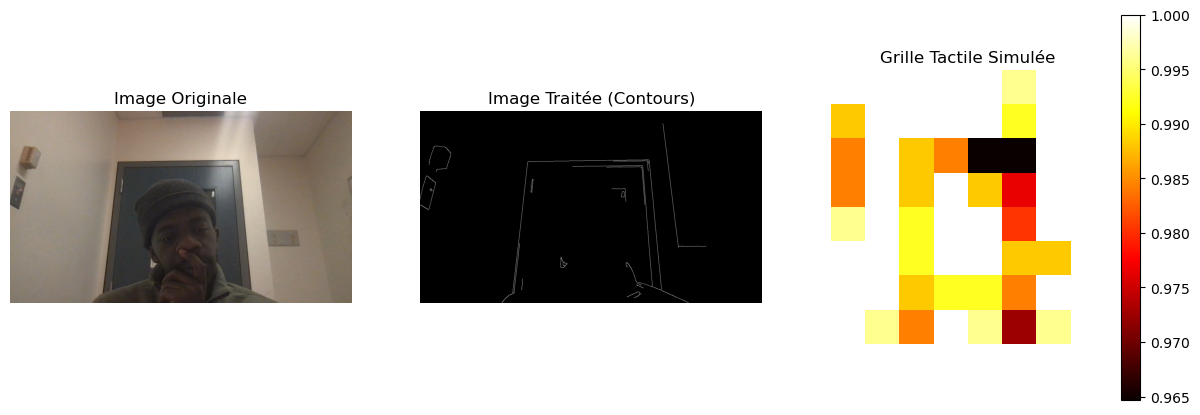

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
TACTILE_RESOLUTION = (8, 8)  # Résolution de la grille tactile (cols, rows)

def capture_image():
    """Capture une image depuis la webcam."""
    cap = cv2.VideoCapture(0)
    ret, frame = cap.read()
    cap.release()
    return frame

def process_image_ia(image):
    """Traite l'image pour en extraire les contours (Approche 1)."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    return edges

def map_to_tactile(processed_image, tactile_resolution):
    """Convertit l'image traitée en une grille tactile."""
    # Redimensionne l'image traitée à la résolution tactile
    resized = cv2.resize(processed_image, tactile_resolution, interpolation=cv2.INTER_AREA)
    # Normalise les valeurs entre 0 et 1
    tactile_grid = resized / 255.0
    # Inverser si nécessaire (pour que les contours soient à 1)
    tactile_grid = 1 - tactile_grid
    return tactile_grid

def visualize_results(original, processed, tactile_grid):
    """Affiche les résultats de la simulation."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Image Originale')
    axes[0].axis('off')

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title('Image Traitée (Contours)')
    axes[1].axis('off')

    # Affiche la grille tactile comme une heatmap
    im = axes[2].imshow(tactile_grid, cmap='hot', interpolation='nearest')
    axes[2].set_title('Grille Tactile Simulée')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2])

    plt.show()

# --- FLUX PRINCIPAL ---
# 1. Capture d'image
original_image = capture_image()
# 2. Traitement par IA
processed_image = process_image_ia(original_image)
# 3. Cartographie Tactile
tactile_grid = map_to_tactile(processed_image, TACTILE_RESOLUTION)
# 4. Simulation Visuelle
visualize_results(original_image, processed_image, tactile_grid)

# 5. (Pour plus tard) Envoi vers le matériel
# print(tactile_grid) # Pourrait être envoyé via serial